## Load in annually separated rainrate amounts and frequencies for XLE

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import metpy
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cf
from functools import partial
import xesmf as xe
import gc
import warnings
import cftime
from scipy import stats
import seaborn as sns
import glob
import yaml
from pathlib import Path
from itertools import combinations
import xcdat
import xclim
import matplotlib.cm as cm
import matplotlib.colors as mcolors

ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/b/beharrop/.conda/envs/myenv2/share/proj failed


In [2]:
datadir     = "/pscratch/sd/b/beharrop/temp/rainrate_testing/remap_stuff"
files       = sorted(glob.glob(f"{datadir}/*_huc2_17.nc"))
year_labels = [int(Path(f).stem[4:8]) for f in files]

ds = xr.concat(
    [xr.open_dataset(f).expand_dims(year=[label])
     for f, label in zip(sorted(files), year_labels)],
    dim='year'
)
ds = ds.mean('ncol')

(0.3, 300)

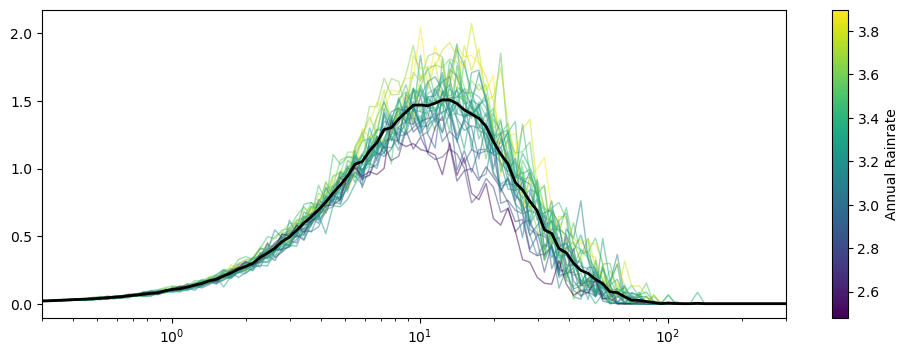

In [3]:
year_sums = np.array([ds['amount'].sel(year=year).sum().values / ds.attrs['inverse_width'] 
                      for year in ds['year']])
norm = mcolors.Normalize(vmin=year_sums.min(), vmax=year_sums.max())
cmap = cm.viridis

fig, ax = plt.subplots(figsize=(12,4))
for year, total in zip(ds['year'], year_sums):
    ax.semilogx(ds['centers'],
                ds['amount'].sel(year=year),
                color=cmap(norm(total)), alpha=0.5, linewidth=1
                )
ax.semilogx(ds['centers'],
            ds['amount'].mean(('year')),
            color='black', linewidth=2
            )

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Annual Rainrate')

ax.set_xlim([0.3, 300])

In [4]:
def moments_from_amount_histogram(amount, centers, include_zero_bin=False, bin_growth_rate=0.07):
    amount = np.asarray(amount, dtype=float)
    centers = np.asarray(centers, dtype=float)

    mask = np.isfinite(amount) & (amount >= 0)

    if not include_zero_bin:
        mask &= centers > 0

    r = centers[mask]
    w = amount[mask]

    total_amount = w.sum()
    if total_amount <= 0:
        raise ValueError("Histogram contains no positive rain amount.")

    w = w / total_amount

    mean = np.sum(w * r)
    centered = r - mean

    m2 = np.sum(w * centered**2)
    m3 = np.sum(w * centered**3)
    m4 = np.sum(w * centered**4)

    std = np.sqrt(m2)
    skew = m3 / m2**1.5
    excess_kurtosis = m4 / m2**2 - 3.0

    return {
        "mean": mean,
        "std": std,
        "skewness": skew,
        "excess_kurtosis": excess_kurtosis,
        "pearson_kurtosis": excess_kurtosis + 3.0,
        "total_amount": bin_growth_rate * total_amount,
    }

In [5]:
ds['amount'].sel(year=1985).values.sum() * 0.07 - (0.07 * ds['amount'].sel(year=1985).values[0])

np.float64(3.4281923944075765)

In [6]:
np.sum(ds['amount'].sel(year=1985).values / ds.attrs['inverse_width'])

np.float64(3.429408465739628)

In [7]:
stats_amount = moments_from_amount_histogram(
    amount=ds['amount'].sel(year=1985).values,
    centers=ds['centers'].values,
    bin_growth_rate=1 / ds.attrs['inverse_width'],
)

In [8]:
stats_amount

{'mean': np.float64(13.695323195227656),
 'std': np.float64(10.981006555395892),
 'skewness': np.float64(1.429391917088193),
 'excess_kurtosis': np.float64(2.206146570548322),
 'pearson_kurtosis': np.float64(5.206146570548322),
 'total_amount': np.float64(3.428192394407576)}

In [9]:
centers         = ds['centers']
bin_growth_rate = 1 / ds.attrs['inverse_width']

# Exclude zero-rate bin; NaN values are skipped by sum
amount_masked = ds['amount'].where(centers > 0)

total    = amount_masked.sum('centers')
w        = amount_masked / total

mean_r   = (w * centers).sum('centers')
centered = centers - mean_r  # broadcasts: (centers,) - (year,) → (year, centers)
m2       = (w * centered**2).sum('centers')
m3       = (w * centered**3).sum('centers')
m4       = (w * centered**4).sum('centers')

ek = m4 / m2**2 - 3.0

stats_all_years = xr.Dataset({
    'mean':             mean_r,
    'std':              np.sqrt(m2),
    'skewness':         m3 / m2**1.5,
    'excess_kurtosis':  ek,
    'pearson_kurtosis': ek + 3.0,
    'total_amount':     bin_growth_rate * total,
})
stats_all_years

<xarray.Dataset> Size: 2kB
Dimensions:           (year: 30)
Coordinates:
  * year              (year) int64 240B 1985 1986 1987 1988 ... 2012 2013 2014
Data variables:
    mean              (year) float64 240B 13.7 12.99 12.31 ... 12.7 13.69 14.28
    std               (year) float64 240B 10.98 10.34 10.12 ... 10.88 12.25
    skewness          (year) float64 240B 1.429 1.627 1.634 ... 1.579 1.74 1.981
    excess_kurtosis   (year) float64 240B 2.206 3.381 3.065 ... 4.546 6.211
    pearson_kurtosis  (year) float64 240B 5.206 6.381 6.065 ... 7.546 9.211
    total_amount      (year) float64 240B 3.428 3.307 2.87 ... 3.175 3.205 3.431

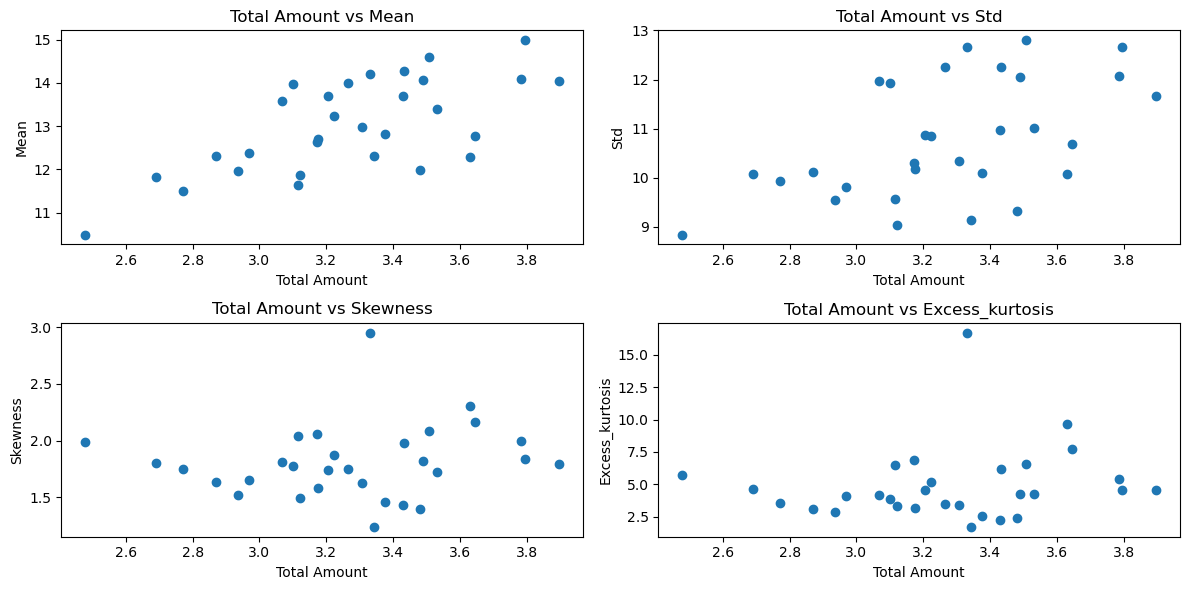

In [10]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12,6))
for ax, metric in zip(axs.flatten(), ['mean', 'std', 'skewness', 'excess_kurtosis']):
    ax.scatter(stats_all_years['total_amount'], stats_all_years[metric])
    ax.set_xlabel('Total Amount')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'Total Amount vs {metric.capitalize()}')
plt.tight_layout()

(0.3, 300)

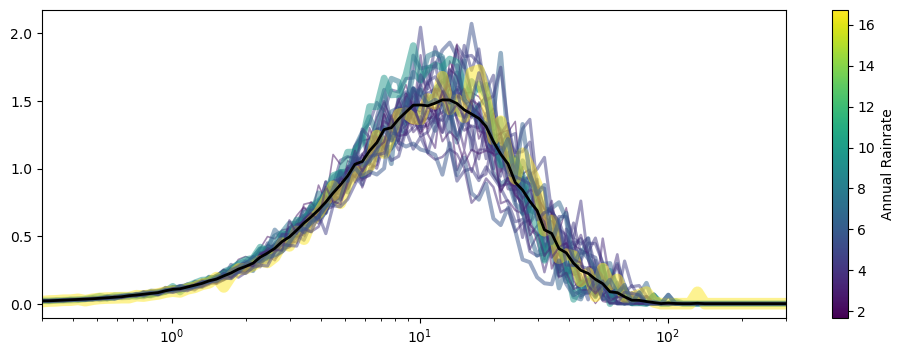

In [11]:
year_sums = stats_all_years['excess_kurtosis']
norm = mcolors.Normalize(vmin=year_sums.min(), vmax=year_sums.max())
cmap = cm.viridis

fig, ax = plt.subplots(figsize=(12,4))
for year, total in zip(ds['year'], year_sums):
    ax.semilogx(ds['centers'],
                ds['amount'].sel(year=year),
                color=cmap(norm(total)), alpha=0.5, linewidth=0.5*year_sums.sel(year=year)
                )
ax.semilogx(ds['centers'],
            ds['amount'].mean(('year')),
            color='black', linewidth=2
            )

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Annual Rainrate')

ax.set_xlim([0.3, 300])

In [12]:
for year in ds['year']:
    print(f"Year: {year.values}, Total Amount: {ds['amount'].sel(year=year).sum().values 
                                                / ds.attrs['inverse_width']}")

Year: 1985, Total Amount: 3.429408465739628
Year: 1986, Total Amount: 3.307788877871316
Year: 1987, Total Amount: 2.871672816593317
Year: 1988, Total Amount: 3.8978205309063694
Year: 1989, Total Amount: 3.481042680837044
Year: 1990, Total Amount: 3.5079589784338223
Year: 1991, Total Amount: 3.3431701851181357
Year: 1992, Total Amount: 3.1022470062564635
Year: 1993, Total Amount: 2.6932958201603125
Year: 1994, Total Amount: 3.784704203509629
Year: 1995, Total Amount: 3.2232195990102492
Year: 1996, Total Amount: 3.532701131556737
Year: 1997, Total Amount: 2.772381570925009
Year: 1998, Total Amount: 2.96945047146083
Year: 1999, Total Amount: 3.6460368590215535
Year: 2000, Total Amount: 3.068254484356103
Year: 2001, Total Amount: 3.376804979358732
Year: 2002, Total Amount: 3.1720821129120984
Year: 2003, Total Amount: 3.1179499956751626
Year: 2004, Total Amount: 3.490698845276438
Year: 2005, Total Amount: 2.936070125043097
Year: 2006, Total Amount: 3.6310461615778973
Year: 2007, Total Amoun

In [13]:
XLE_members = ['0051', '0091', '0101', '0111', '0121',
                 '0131', '0141', '0151', '0161', '0171',
                 '0181', '0191', '0201', '0211', '0221',
                 '0231', '0241', '0251', '0261', '0271',
                 '0281', '0291', '0301', '0311', '0321',
                ]
               
  # --- E3SMv3 ---
E3SMv3_files = [f'E3SMv3/v3.LR.historical_{ens}.csv' for ens in XLE_members]
E3SMv3_files

['E3SMv3/v3.LR.historical_0051.csv',
 'E3SMv3/v3.LR.historical_0091.csv',
 'E3SMv3/v3.LR.historical_0101.csv',
 'E3SMv3/v3.LR.historical_0111.csv',
 'E3SMv3/v3.LR.historical_0121.csv',
 'E3SMv3/v3.LR.historical_0131.csv',
 'E3SMv3/v3.LR.historical_0141.csv',
 'E3SMv3/v3.LR.historical_0151.csv',
 'E3SMv3/v3.LR.historical_0161.csv',
 'E3SMv3/v3.LR.historical_0171.csv',
 'E3SMv3/v3.LR.historical_0181.csv',
 'E3SMv3/v3.LR.historical_0191.csv',
 'E3SMv3/v3.LR.historical_0201.csv',
 'E3SMv3/v3.LR.historical_0211.csv',
 'E3SMv3/v3.LR.historical_0221.csv',
 'E3SMv3/v3.LR.historical_0231.csv',
 'E3SMv3/v3.LR.historical_0241.csv',
 'E3SMv3/v3.LR.historical_0251.csv',
 'E3SMv3/v3.LR.historical_0261.csv',
 'E3SMv3/v3.LR.historical_0271.csv',
 'E3SMv3/v3.LR.historical_0281.csv',
 'E3SMv3/v3.LR.historical_0291.csv',
 'E3SMv3/v3.LR.historical_0301.csv',
 'E3SMv3/v3.LR.historical_0311.csv',
 'E3SMv3/v3.LR.historical_0321.csv']

In [14]:
ds_temp  = xr.open_dataset(datadir + '/RRA_1985.nc')
ds_temp2 = xr.open_dataset('/global/cfs/cdirs/e3smdata/simulations/v3.XLE/v3.LR.historical_0051/' + 
                           'archive/atm/hist/v3.LR.historical_0051.eam.h1.1985-01-16-00000.nc')
ds_temp, ds_temp2

(<xarray.Dataset> Size: 26MB
 Dimensions:  (centers: 152, ncol: 21600, edges: 153)
 Coordinates:
   * centers  (centers) float64 1kB 0.0 0.03 0.0321 0.03435 ... 669.8 716.6 766.8
   * ncol     (ncol) int64 173kB 0 1 2 3 4 5 ... 21595 21596 21597 21598 21599
   * edges    (edges) float64 1kB 0.0 0.029 0.03103 0.0332 ... 692.8 741.3 793.2
 Data variables:
     amount   (centers, ncol) float64 26MB ...
 Attributes:
     Smallest bin center:       0.03
     growth factor percentage:  1.07
     center to edge factor:     0.029002094671369907
     inverse_width:             14.285714285714285
     author:                    Bryce Harrop,
 <xarray.Dataset> Size: 34MB
 Dimensions:              (ncol: 21600, lev: 80, ilev: 81, cosp_prs: 7, nbnd: 2,
                           cosp_tau: 7, cosp_ht: 40, cosp_temp: 40, cosp_sr: 15,
                           cosp_htmisr: 16, cosp_tau_modis: 7, cosp_reffice: 6,
                           cosp_reffliq: 6, time: 30, P3_input_dim: 16,
                 

## Load Monthly Timeseries Data for the Three Large Ensembles

Load `TREFHT`, `PRECC`, and `PRECL` from the three XLE large ensembles
(`v3.LR.historical`, `v3.LR.highECS.historical`, `v3.LR.lowECS.historical`).
Each dataset has dimensions `(ensemble, time, rgn)`.
Members whose files are partially or fully absent are skipped automatically.

In [15]:
# ── Configuration ─────────────────────────────────────────────────────────────
XLE_PARENT_DIR = Path("/global/cfs/cdirs/e3smdata/simulations/v3.XLE")

# All 25 target member IDs (same across all three large ensembles)
MEMBER_IDS = [
    "0051", "0091", "0101", "0111", "0121", "0131", "0141", "0151",
    "0161", "0171", "0181", "0191", "0201", "0211", "0221", "0231",
    "0241", "0251", "0261", "0271", "0281", "0291", "0301", "0311", "0321",
]

# Map short name → directory prefix for each large ensemble
ENSEMBLE_PREFIXES = {
    "default": "v3.LR.historical",
    "highECS": "v3.LR.highECS.historical",
    "lowECS":  "v3.LR.lowECS.historical",
}

# Variables to load
VARIABLES = ["TREFHT", "PRECC", "PRECL"]

In [16]:
def load_large_ensemble(prefix, member_ids, variables, parent_dir):
    """
    Load monthly timeseries data for one E3SM large ensemble.

    For each member in `member_ids` the function globs all 5-yr NetCDF chunks
    under  <parent_dir>/<prefix>_<member_id>/post/atm/glb/ts/monthly/5yr/
    for every variable in `variables`, concatenates them along the time
    dimension, and stacks the result along a new `ensemble` dimension.

    A member is silently skipped if *any* requested variable has no matching
    files, keeping the returned Dataset complete and rectangular.

    Parameters
    ----------
    prefix : str
        Directory prefix for the ensemble, e.g. "v3.LR.highECS.historical".
    member_ids : list of str
        Candidate member IDs to attempt loading (e.g. ["0051", "0091", ...]).
    variables : list of str
        Variable names to load (e.g. ["TREFHT", "PRECC", "PRECL"]).
    parent_dir : Path
        Root directory containing all ensemble member subdirectories.

    Returns
    -------
    ds : xr.Dataset or None
        Dataset with dimensions (ensemble, time, rgn).  Returns None if no
        members could be loaded.
    loaded_members : list of str
        Member IDs that were successfully loaded.
    """
    member_datasets = []
    loaded_members  = []

    for member_id in member_ids:
        ts_dir = (
            parent_dir
            / f"{prefix}_{member_id}"
            / "post" / "atm" / "glb" / "ts" / "monthly" / "5yr"
        )

        # Collect all time-chunk files for each variable
        var_data_arrays = {}
        all_vars_present = True

        for var in variables:
            files = sorted(ts_dir.glob(f"{var}_*.nc"))
            if not files:
                all_vars_present = False
                break
            # Concatenate any multiple 5-yr chunks along the time axis
            ds_var = xr.open_mfdataset(
                files,
                combine="nested",
                concat_dim="time",
                data_vars="minimal",
                coords="minimal",
                compat="override",
            )
            var_data_arrays[var] = ds_var[var]

        if not all_vars_present:
            print(f"  [SKIP] {prefix}_{member_id}: one or more variables absent")
            continue

        member_datasets.append(xr.Dataset(var_data_arrays))
        loaded_members.append(member_id)

    if not member_datasets:
        print(f"  [WARNING] No members loaded for {prefix}")
        return None, []

    ds_ensemble = xr.concat(member_datasets, dim="ensemble")
    ds_ensemble = ds_ensemble.assign_coords(ensemble=loaded_members)

    return ds_ensemble, loaded_members


# ── Load all three large ensembles ────────────────────────────────────────────
print("Loading v3.LR.historical …")
ds_default, members_default = load_large_ensemble(
    ENSEMBLE_PREFIXES["default"], MEMBER_IDS, VARIABLES, XLE_PARENT_DIR
)
n_members_default = len(members_default)
print(f"  {n_members_default} / {len(MEMBER_IDS)} members loaded\n")

print("Loading v3.LR.highECS.historical …")
ds_highECS, members_highECS = load_large_ensemble(
    ENSEMBLE_PREFIXES["highECS"], MEMBER_IDS, VARIABLES, XLE_PARENT_DIR
)
n_members_highECS = len(members_highECS)
print(f"  {n_members_highECS} / {len(MEMBER_IDS)} members loaded\n")

print("Loading v3.LR.lowECS.historical …")
ds_lowECS, members_lowECS = load_large_ensemble(
    ENSEMBLE_PREFIXES["lowECS"], MEMBER_IDS, VARIABLES, XLE_PARENT_DIR
)
n_members_lowECS = len(members_lowECS)
print(f"  {n_members_lowECS} / {len(MEMBER_IDS)} members loaded\n")

print("Summary")
print(f"  default    : {n_members_default} members — {members_default}")
print(f"  highECS    : {n_members_highECS} members — {members_highECS}")
print(f"  lowECS     : {n_members_lowECS} members — {members_lowECS}")

Loading v3.LR.historical …
  25 / 25 members loaded

Loading v3.LR.highECS.historical …
  25 / 25 members loaded

Loading v3.LR.lowECS.historical …
  25 / 25 members loaded

Summary
  default    : 25 members — ['0051', '0091', '0101', '0111', '0121', '0131', '0141', '0151', '0161', '0171', '0181', '0191', '0201', '0211', '0221', '0231', '0241', '0251', '0261', '0271', '0281', '0291', '0301', '0311', '0321']
  highECS    : 25 members — ['0051', '0091', '0101', '0111', '0121', '0131', '0141', '0151', '0161', '0171', '0181', '0191', '0201', '0211', '0221', '0231', '0241', '0251', '0261', '0271', '0281', '0291', '0301', '0311', '0321']
  lowECS     : 25 members — ['0051', '0091', '0101', '0111', '0121', '0131', '0141', '0151', '0161', '0171', '0181', '0191', '0201', '0211', '0221', '0231', '0241', '0251', '0261', '0271', '0281', '0291', '0301', '0311', '0321']


In [17]:
# ── Compute total precipitation rate (PRECT) from convective and large-scale components ──

for ds in [ds_default, ds_highECS, ds_lowECS]:
    ds['PRECT'] = 86400e3 * (ds['PRECC'] + ds['PRECL'])
    ds['PRECT'].attrs.update({
        'long_name': 'Total precipitation rate (liq + ice)',
        'units': 'mm/day',
    })


In [18]:
# ── Add time bounds variables and center time coordinates ─────────────────────

def add_time_bnds(ds):
    """
    Add a time_bnds variable to a dataset whose time coordinate represents
    the right bound of each monthly interval (i.e., first day of the following
    month).  The left bound is set to the first day of the current month at
    00:00:00, matching the E3SM convention.
    """
    times = ds["time"].values

    def left_bound(dt):
        year, month = dt.year, dt.month - 1
        if month == 0:
            month, year = 12, year - 1
        return type(dt)(year, month, 1, 0, 0, 0, 0, has_year_zero=dt.has_year_zero)

    left_bnds  = np.array([left_bound(t) for t in times])
    right_bnds = times

    time_bnds = xr.DataArray(
        np.array(list(zip(left_bnds, right_bnds))),
        dims=["time", "bnds"],
        coords={"time": ds["time"]},
    )
    ds = ds.assign({"time_bnds": time_bnds})
    ds["time"].attrs["bounds"] = "time_bnds"
    return ds

ds_default = xcdat.center_times(add_time_bnds(ds_default))
ds_highECS = xcdat.center_times(add_time_bnds(ds_highECS))
ds_lowECS  = xcdat.center_times(add_time_bnds(ds_lowECS))


## Testing stuff

In [120]:
root = "/global/cfs/cdirs/m3522/datalake/CMIP6/CMIP"
output_dir = "/global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv"


def discover_models(root):
    """Map each model name to its (modeling center, realization) pairs found under root."""
    models = {}
    paths = sorted(glob.glob(os.path.join(root, "*", "*", "historical", "r?i1p1f1")))
    for path in paths:
        center, model, _experiment, realization = os.path.relpath(path, root).split(os.sep)
        entries = models.setdefault(model, [])
        if entries and entries[0][0] != center:
            print(f"WARNING: {model} found under multiple centers ({entries[0][0]}, {center})")
        entries.append((center, realization))
    for model, entries in sorted(models.items()):
        print(f"{model}: {len(entries)} realization(s)")
    return models


def realization_number(realization):
    """Extract the ensemble number from a realization label like 'r3i1p1f1'."""
    return re.match(r"^r(\d+)i", realization).group(1)


def find_latest_files(root, center, model, realization):
    """Locate tas files for the latest available version, searching across grid labels."""
    base = os.path.join(root, center, model, "historical", realization, "Amon", "tas")
    for grid_dir in sorted(glob.glob(os.path.join(base, "*"))):
        version_dirs = sorted(glob.glob(os.path.join(grid_dir, "v*")))
        if not version_dirs:
            continue
        files = sorted(glob.glob(os.path.join(version_dirs[-1], "tas_Amon_*_*.nc")))
        if files:
            return files
    return []


def monthly_spatial_mean(ds_in, lat_bounds=(-90,90)):
    return ds_in.spatial.average(
        data_var="tas",
        axis=["X", "Y"],
        weights="generate",
        lat_bounds=lat_bounds,
    )

def annual_day_weighted_mean(ds_in, data_var="tas", weighted=True):
    return ds_in.temporal.group_average(data_var, freq="year", weighted=weighted)


def _tas_values(annual_mean):
    # spatial.average() returns a Dataset, but be tolerant of a bare DataArray too.
    return annual_mean["tas"].values if isinstance(annual_mean, xr.Dataset) else annual_mean.values


def process_realization(root, output_dir, center, model, realization):
    n = realization_number(realization)
    out_path = os.path.join(output_dir, f"{model}_r{n}.csv")
    incomplete_path = os.path.join(output_dir, f"{model}_r{n}_incomplete.csv")
    if os.path.exists(out_path) or os.path.exists(incomplete_path):
        print(f"Skipping {model} {realization}, output already exists")
        return

    files = find_latest_files(root, center, model, realization)
    if not files:
        print(f"WARNING: no tas files found for {model} {realization}, skipping")
        return

    print(f"Processing {model} {realization}")
    try:
        ds = xcdat.open_mfdataset(files, combine="by_coords", chunks={"time": 120}, lon_orient=(-180,180))
        ds = ds.bounds.add_missing_bounds()

        tas_global_annual = annual_day_weighted_mean(
            monthly_spatial_mean(ds, lat_bounds=(-90, 90))
        )
        tas_nh_annual = annual_day_weighted_mean(
            monthly_spatial_mean(ds, lat_bounds=(0, 90))
        )
        tas_sh_annual = annual_day_weighted_mean(
            monthly_spatial_mean(ds, lat_bounds=(-90, 0))
        )

        year = tas_global_annual['time'].dt.year.values
        data = np.column_stack(
            [
                year.astype("float64"),
                _tas_values(tas_global_annual),
                _tas_values(tas_nh_annual),
                _tas_values(tas_sh_annual),
            ]
        )
    except Exception as exc:
        print(f"WARNING: failed to process {model} {realization}: {exc}")
        return

    if len(year) != 165 or year.min() != 1850 or year.max() != 2014:
        print(f"NOTE: {model} {realization} spans {year.min()}-{year.max()} ({len(year)} years)")
        out_path = incomplete_path

    np.savetxt(out_path, data, delimiter=",")




In [102]:
model = 'CESM2'
center, realization = models[model][0]
print(model, center, realization)
# center, realization = models[model]#.items()
files = find_latest_files(root, center, model, realization)
ds = xcdat.open_mfdataset(files, combine="by_coords", chunks={"time": 120}, lon_orient=(-180,180))
ds = ds.bounds.add_missing_bounds()
ds = xcdat.center_times(ds)
ds
# for model, entries in sorted(models.items()):
#     for center, realization in entries:
#         process_realization(root, output_dir, center, model, realization)

CESM2 NCAR r1i1p1f1


/global/homes/b/beharrop/.conda/envs/myenv2/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 438MB dask.array<chunksize=(120, 192, 288), meta=np.ndarray>
    time_bnds  (time, nbnd) object 32kB dask.array<chunksize=(120, 2), meta=np.ndarray>
    lat_bnds   (lat, nbnd) float32 2kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lon_bnds   (lon, nbnd) float32 2kB dask.array<chunksize=(288, 2), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T23:34:05Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [103]:
tas_global_annual = annual_day_weighted_mean(
            monthly_spatial_mean(ds, lat_bounds=(-90, 90))
        )

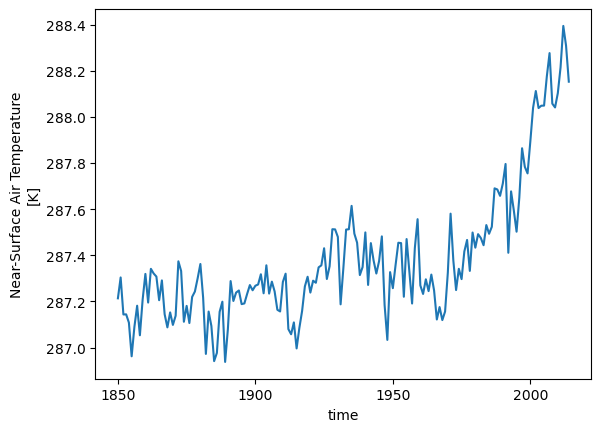

In [101]:
tas_global_annual['tas'].plot()